와인데이터셋 이용
- train, test 나누기
- 정규화 하기
- 앙상블 이용하여 train, test (정확도, f1 score, confusion matrix) 확인하기
- 부스팅 모델을 이용한 train,test (정확도, f1 score, confusion matrix) 확인하기

iris 데이터셋 이용
- 군집화 하기
- 정답과 군집화값 정확도 확인하기

In [1]:
import pandas as pd
import numpy as np
import mglearn
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier
from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sb
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family']='Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

- 와인데이터셋 이용

In [2]:
wine = load_wine()

In [3]:
x_data = wine.data
y_data = wine.target

In [4]:
# wine_df = pd.DataFrame(wine.data, columns=wine.feature_names)
# wine_df['target'] = wine.target

# print(wine_df.head())
# wine_df

- train, test 나누기
- 정규화 하기

In [5]:
# 정규화
scale = StandardScaler()
x_dataScale = scale.fit_transform(x_data)

In [6]:
# split
x_train, x_test, y_train, y_test = train_test_split( x_dataScale, y_data, test_size=0.2, stratify=y_data)

- 앙상블(voting) 이용하여 train, test (정확도, f1 score, confusion matrix) 확인하기

In [7]:
# voting
logistic = LogisticRegression(max_iter=500)
knn = KNeighborsClassifier(n_neighbors=5)
tree = DecisionTreeClassifier(min_samples_leaf=5)

model_voting = VotingClassifier([('logistic',logistic),('knn',knn),('tree',tree)], voting='soft')
model_voting.fit(x_train, y_train)
pred_train_voting = model_voting.predict(x_train)
pred_test_voting = model_voting.predict(x_test)

정확도 0.9859154929577465
f1 score 0.9862098427887901
[[47  0  0]
 [ 1 55  1]
 [ 0  0 38]]


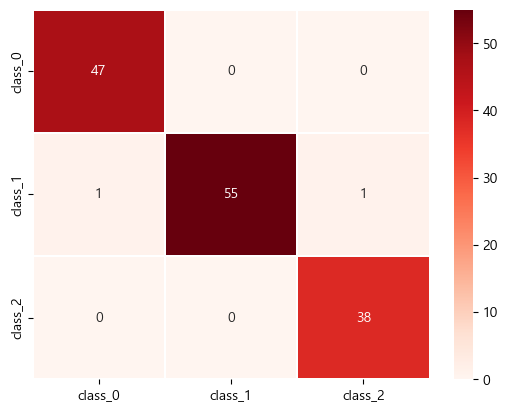

In [8]:
# train
print('정확도', accuracy_score(y_train, pred_train_voting) )
print('f1 score', f1_score(y_train, pred_train_voting, average='macro') )
cmt_train_voting = confusion_matrix(y_train, pred_train_voting)
print(cmt_train_voting)
sb.heatmap(cmt_train_voting, annot=True, fmt='d',linewidths=0.2, cmap='Reds', xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.show()

정확도 0.9444444444444444
f1 score 0.9451526251526251
[[12  0  0]
 [ 1 12  1]
 [ 0  0 10]]


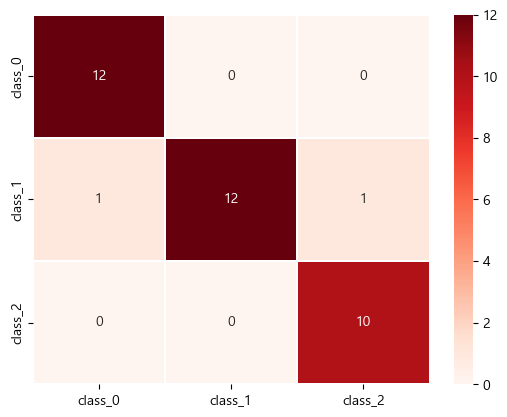

In [9]:
# test
print('정확도', accuracy_score(y_test, pred_test_voting) )
print('f1 score', f1_score(y_test, pred_test_voting, average='macro') )
cmt_test_voting = confusion_matrix(y_test, pred_test_voting)
print(cmt_test_voting)
sb.heatmap(cmt_test_voting, annot=True, fmt='d',linewidths=0.2, cmap='Reds', xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.show()

- 부스팅 모델을 이용한 train,test (정확도, f1 score, confusion matrix) 확인하기

In [10]:
model_cat = CatBoostClassifier(random_state=42, verbose=0)
model_cat.fit(x_train, y_train)
pred_train_cat = model_cat.predict(x_train)
pred_test_cat = model_cat.predict(x_test)

정확도 1.0
f1 score 1.0
[[47  0  0]
 [ 0 57  0]
 [ 0  0 38]]


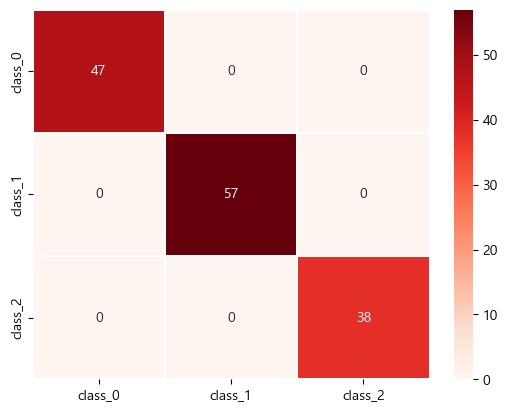

In [11]:
# train
print('정확도', accuracy_score(y_train, pred_train_cat) )
print('f1 score', f1_score(y_train, pred_train_cat, average='macro') )
cmt_train_cat = confusion_matrix(y_train, pred_train_cat)
print(cmt_train_cat)
sb.heatmap(cmt_train_cat, annot=True, fmt='d',linewidths=0.2, cmap='Reds', xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.show()

정확도 0.9722222222222222
f1 score 0.9717813051146384
[[12  0  0]
 [ 0 13  1]
 [ 0  0 10]]


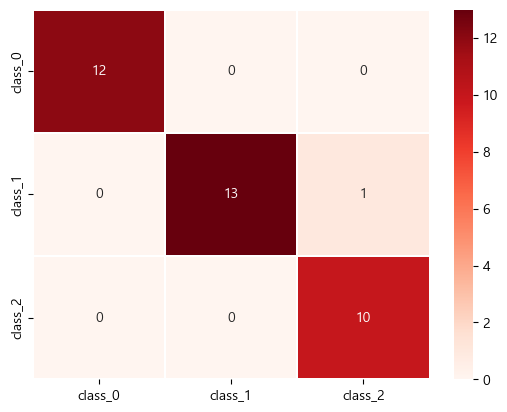

In [12]:
# test
print('정확도', accuracy_score(y_test, pred_test_cat) )
print('f1 score', f1_score(y_test, pred_test_cat, average='macro') )
cmt_test_cat = confusion_matrix(y_test, pred_test_cat)
print(cmt_test_cat)
sb.heatmap(cmt_test_cat, annot=True, fmt='d',linewidths=0.2, cmap='Reds', xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.show()

iris 데이터셋 이용

In [13]:
iris = load_iris(as_frame=True)
iris.data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [14]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

- 군집화 하기

In [15]:
k = KMeans(n_clusters=3)
km = k.fit(iris.data)

In [16]:
km.cluster_centers_

array([[5.88360656, 2.74098361, 4.38852459, 1.43442623],
       [6.85384615, 3.07692308, 5.71538462, 2.05384615],
       [5.006     , 3.428     , 1.462     , 0.246     ]])

- 정답과 군집화값 정확도 확인하기

In [17]:
df = iris.data.copy()
df['cluster'] = km.labels_
df['target'] = iris.target

pd.crosstab(df['cluster'], df['target'])

target,0,1,2
cluster,,,
0,0,47,14
1,0,3,36
2,50,0,0


In [18]:
cluster_to_label = (
	df.groupby('cluster')['target']
	  .agg(lambda x: x.value_counts().idxmax())
)

cluster_to_label

cluster
0    1
1    2
2    0
Name: target, dtype: int32

In [19]:
y_pred = df['cluster'].map(cluster_to_label)
accuracy_score(df['target'], y_pred)

0.8866666666666667